In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
!curl -L https://github.com/ardipazij/s21_ML/raw/main/data/train.json -o train.json

In [4]:
raw_train_df = pd.read_json("train.json")

In [5]:
def preprocess_data(df, is_train=True):
    # Очистка выбросов
    for col in ["price", "bathrooms"]:
        if col in df.columns:
            lb = df[col].quantile(0.01)
            ub = df[col].quantile(0.99)
            df = df[(df[col] >= lb) & (df[col] <= ub)]
    
    df["features"] = df["features"].astype(str).str.replace(r"[\[\]'\" ]", "", regex=True)
    return df

raw_train_df = preprocess_data(raw_train_df)


In [6]:
all_features = []
for f_str in raw_train_df["features"]:
    all_features.extend([f for f in f_str.split(",") if f != ""])
top_20 = [f for f, _ in Counter(all_features).most_common(20)]

for feature in top_20:
    raw_train_df[feature] = raw_train_df["features"].apply(lambda x: 1 if feature in x else 0)

In [7]:
# EУдаляем нерепрезентативные данные
cols_to_drop = ["building_id", "description", "display_address", "features", "manager_id", 
                "photos", "street_address", "latitude", "listing_id", "longitude", "interest_level", "created"]
X = raw_train_df.drop(columns=[c for c in cols_to_drop if c in raw_train_df.columns] + ["price"])
y = raw_train_df["price"]

In [8]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

In [9]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

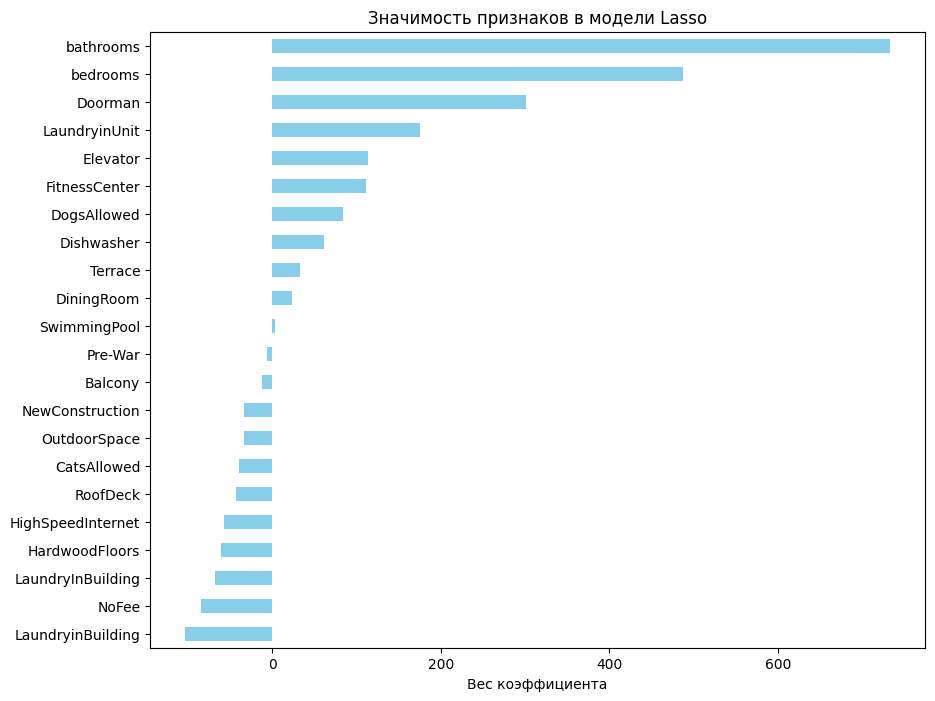

In [10]:
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)

def plot_importance(model, features, name):
    coef = pd.Series(model.coef_, index=features).sort_values()
    plt.figure(figsize=(10, 8))
    coef.plot(kind='barh', color='skyblue')
    plt.title(f'Значимость признаков в модели {name}')
    plt.xlabel('Вес коэффициента')
    plt.show()

plot_importance(lasso, X.columns, "Lasso")

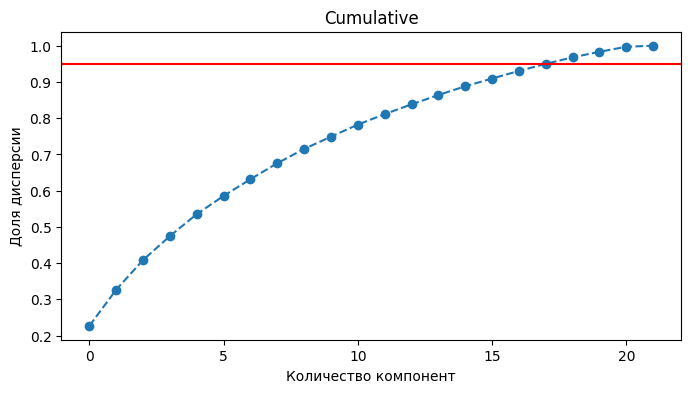

In [12]:
pca = PCA()
X_pca_train = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative')
plt.xlabel('Количество компонент')
plt.ylabel('Доля дисперсии')
plt.axhline(y=0.95, color='r', linestyle='-') # порог 95%
plt.show()

In [ ]:

# Обучаем Lasso на данных после PCA (возьмем, например, 10 компонент)
n_comp = 10
pca_final = PCA(n_components=n_comp)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_val_pca = pca_final.transform(X_val_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

model_pca = Lasso(alpha=1.0)
model_pca.fit(X_train_pca, y_train)

# --- 5. Сравнение и Графики реальных значений ---
def evaluate_and_plot(model, X_set, y_set, name):
    preds = model.predict(X_set)
    r2 = r2_score(y_set, preds)
    mse = mean_squared_error(y_set, preds)
    
    print(f"--- {name} ---")
    print(f"R2: {r2:.4f}, MSE: {mse:.2f}")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(y_set, preds, alpha=0.3, color='green')
    plt.plot([y_set.min(), y_set.max()], [y_set.min(), y_set.max()], 'r--', lw=2)
    plt.title(f'План vs Факт: {name}\n$R^2$ = {r2:.3f}')
    plt.xlabel('Реальная цена')
    plt.ylabel('Предсказанная цена')
    plt.show()

evaluate_and_plot(lasso, X_test_scaled, y_test, "Lasso (Original Features)")
evaluate_and_plot(model_pca, X_test_pca, y_test, f"Lasso (after PCA-{n_comp})")